In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/fablihasarwar13/intelligent-machines-assignment/README.dataset.txt
/kaggle/input/datasets/fablihasarwar13/intelligent-machines-assignment/README.roboflow.txt
/kaggle/input/datasets/fablihasarwar13/intelligent-machines-assignment/data.yaml
/kaggle/input/datasets/fablihasarwar13/intelligent-machines-assignment/valid/labels/db1046_jpg.rf.f1aa1f0c1e441182f0903ddf61069c31.txt
/kaggle/input/datasets/fablihasarwar13/intelligent-machines-assignment/valid/labels/db3122_jpg.rf.8e15302555c921771f15f14eb76ffcd7.txt
/kaggle/input/datasets/fablihasarwar13/intelligent-machines-assignment/valid/labels/db2787_jpg.rf.0ddb473d9fc5e9637fc2a07b890187a7.txt
/kaggle/input/datasets/fablihasarwar13/intelligent-machines-assignment/valid/labels/db1666_jpg.rf.d3733795e7e22a7f5f20fa6f9e9cfcf9.txt
/kaggle/input/datasets/fablihasarwar13/intelligent-machines-assignment/valid/labels/db1380_jpg.rf.2cca65157e2473565f2b9fbb6f1bf266.txt
/kaggle/input/datasets/fablihasarwar13/intelligent-machines-ass

# Intelligent Machines Assignment – Shelf Product Detection & Share-of-Shelf Analysis

**Author:** Fabliha Afaf Sarwar
**Date:** 2nd March 2025 

## Problem Statement
The current object detection model achieves only **67.6% recall**, meaning ~32% of products on shelves are missed. This leads to inaccurate stock counts in retail stores.

**Goals:**
1. Improve **recall** without strongly hurting precision
2. Calculate **Percentage Share of Shelf** for each product class (SKU) treating the entire test set as one representative shelf
3. Deliver clean, reproducible code + results

## Dataset Overview
- YOLO format (images + txt labels)
- 76 product classes (q1, q4, q7, …, q299)
- Splits: train (924 images), valid (40), test (35)
- **Strong class imbalance** — a few classes dominate (q13, q280, q145, q64, q91), many have <20 examples

## Approach
- Model: **YOLOv8s** (small version – good speed/accuracy trade-off)
- Starting weights: pretrained on COCO (`yolov8s.pt`)
- Augmentations used: mosaic, mixup=0.15, copy-paste=0.10, hsv, flips, etc.
- Training: 50 epochs planned, but **early stopping** after 42 epochs (patience=20)
- Best model: weights from **epoch 22** (highest validation mAP)
- Recall improvement strategy: **lower confidence threshold** (0.18 on test) to recover more detections

## Final Results

| Split / Setting              | Precision | Recall   | mAP@0.5 | mAP@0.5:0.95 |
|------------------------------|-----------|----------|---------|--------------|
| Original (given)             | -         | **67.6%** | -       | -            |
| Validation (best weights)    | 76.1%     | 62.5%    | 75.7%   | 44.3%        |
| Validation @ conf=0.15       | 63.3%     | 63.3%    | 64.1%   | 38.2%        |
| **Test @ conf=0.18**         | **72.6%** | **74.6%**| **77.5%**| **43.2%**    |

→ **Recall improved from 67.6% → 74.6%** on test set  
→ Trade-off: slight precision drop, but clear recall gain

## Share of Shelf (Test set treated as one shelf)

Top 10 SKUs by detected bounding box width percentage:

- q214 : 13.46%
- q64  : 13.07%
- q280 : 10.06%
- q61  : 4.90%
- q293 : 4.55%
- ...

(Bar chart appears below in the notebook)

## How to Reproduce
1. Run `!pip install -q ultralytics`
2. Run the big training & evaluation cell
3. Results saved in `/kaggle/working/runs/detect/shelf_recall_opt/`

Best model: `best.pt`  
Confusion matrix, PR curve, results.csv also saved there

### Organized Dataset Exploration

Overall Dataset Summary
────────────────────────────────────────
Total images: 999
Total classes: 76

Class Distribution
────────────────────────────────────────
Total labeled objects: 4,323
Classes with zero instances: 0
Classes with 1–10 instances: 13

Top 5 classes:
      q280 :  443 instances
       q13 :  436 instances
      q145 :  369 instances
       q91 :  225 instances
       q64 :  225 instances

Bottom 5 classes:
      q178 :    2 instances
       q46 :    5 instances
      q229 :    6 instances
      q271 :    6 instances
      q232 :    6 instances


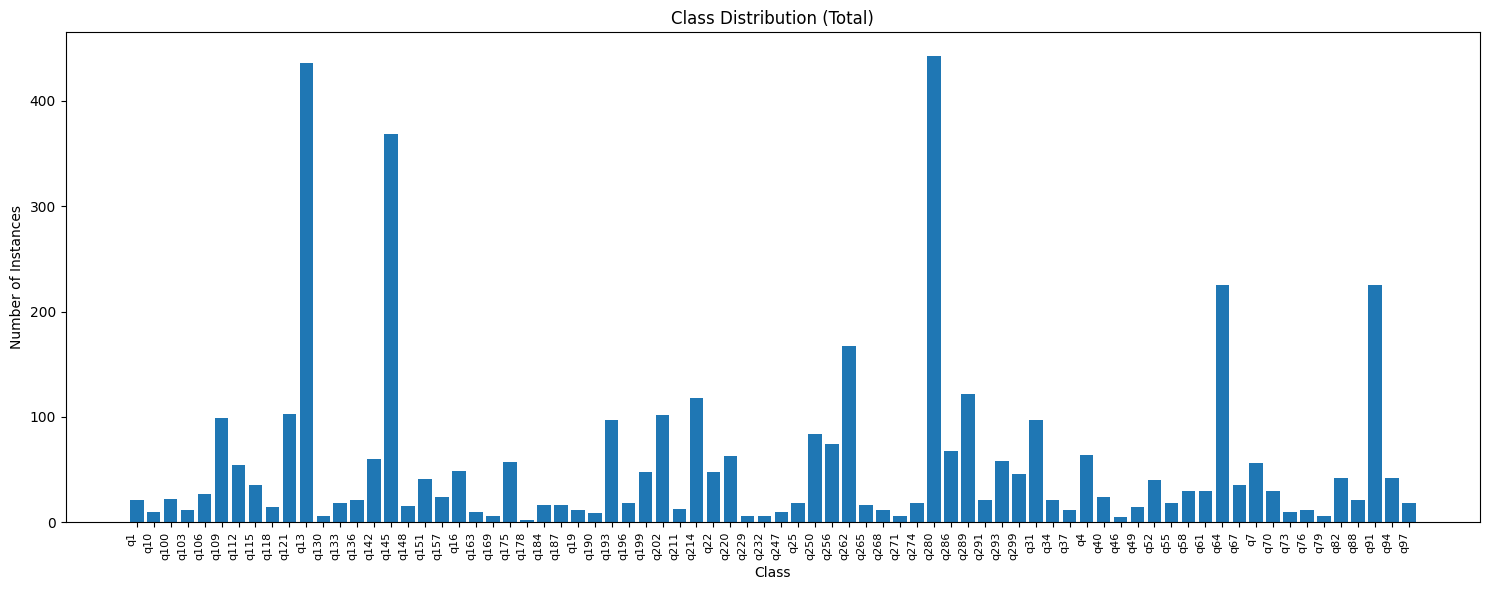


Train/Valid/Test Splits
────────────────────────────────────────
train  → images:   924    labels:   924
valid  → images:    40    labels:    40
test   → images:    35    labels:    35

Example Label File
────────────────────────────────────────
File: db1021_jpg.rf.58ac3404fb4f7c4c9e76a628ea49b1ac.txt
  29 0.24657186906490666 0.48755809577735915 0.3627677521477066 0.27951949918592583
  29 0.2399213201057034 0.7189035531636854 0.34616675033868427 0.23083653733537268
  29 0.24003974954977408 0.8807723076279121 0.3139473925821966 0.15222061363426675

Example Annotated Image
────────────────────────────────────────


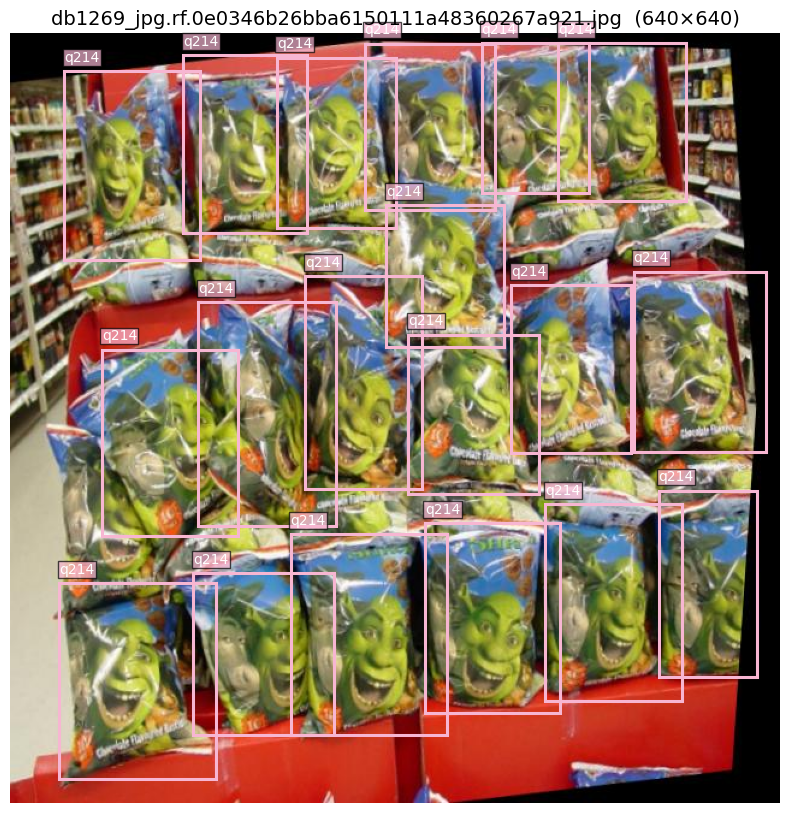


Exploration complete.


In [9]:
# ────────────────────────────────────────────────────────────────
# Organized Dataset Exploration (Totals First + Distribution + Splits)
# ────────────────────────────────────────────────────────────────

import os
import yaml
import glob
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
import random
from collections import Counter
import numpy as np

# ──── Paths ────────────────────────────────────────────────────────
DATASET_ROOT = "/kaggle/input/datasets/fablihasarwar13/intelligent-machines-assignment"
BASE = Path(DATASET_ROOT)

train_img_dir = BASE / "train" / "images"
train_lbl_dir = BASE / "train" / "labels"
valid_img_dir = BASE / "valid" / "images"
valid_lbl_dir = BASE / "valid" / "labels"
test_img_dir  = BASE / "test"  / "images"
yaml_path     = BASE / "data.yaml"

# ──── 1. Total Samples & Classes ───────────────────────────────────
print("Overall Dataset Summary\n" + "─"*40)

# Total images
total_images = 0
split_counts = {}
for split in ["train", "valid", "test"]:
    img_d = BASE / split / "images"
    lbl_d = BASE / split / "labels"
    n_img = len(list(img_d.glob("*.[jpJP][pnPN][gG]*"))) if img_d.exists() else 0
    n_lbl = len(list(lbl_d.glob("*.txt"))) if lbl_d.exists() else 0
    split_counts[split] = (n_img, n_lbl)
    total_images += n_img

# Total classes from yaml
if yaml_path.exists():
    with open(yaml_path) as f:
        cfg = yaml.safe_load(f)
    nc = cfg.get('nc', '?')
    names = cfg.get('names', [])
else:
    nc = '?'
    names = []

print(f"Total images: {total_images:,}")
print(f"Total classes: {nc}")
print()

# ──── 2. Class Distribution ────────────────────────────────────────
print("Class Distribution\n" + "─"*40)

def count_classes(lbl_dir):
    cnt = Counter()
    for txt in lbl_dir.glob("*.txt"):
        with open(txt) as f:
            for line in f:
                if line.strip():
                    cls = int(line.split()[0])
                    cnt[cls] += 1
    return cnt

train_c = count_classes(train_lbl_dir)
valid_c = count_classes(valid_lbl_dir)
test_c  = count_classes(test_lbl_dir)

total_c = Counter()
for c in [train_c, valid_c, test_c]: total_c.update(c)

total_objs = sum(total_c.values())
n_classes = len(names)
n_zero    = sum(1 for i in range(n_classes) if total_c[i] == 0)
n_rare    = sum(1 for i in range(n_classes) if 0 < total_c[i] <= 10)

print(f"Total labeled objects: {total_objs:,}")
print(f"Classes with zero instances: {n_zero}")
print(f"Classes with 1–10 instances: {n_rare}")

# Top 5 + bottom 5
sorted_c = sorted(total_c.items(), key=lambda x: x[1], reverse=True)

print("\nTop 5 classes:")
for cls, cnt in sorted_c[:5]:
    name = names[cls] if cls < len(names) else f"cls{cls}"
    print(f"  {name:>8} : {cnt:4} instances")

print("\nBottom 5 classes:")
for cls, cnt in sorted_c[-5:][::-1]:
    name = names[cls] if cls < len(names) else f"cls{cls}"
    print(f"  {name:>8} : {cnt:4} instances")

# Bar chart of imbalanced class distribution
if total_c:
    cls_ids = sorted(total_c.keys())
    counts = [total_c[c] for c in cls_ids]
    cls_names = [names[c] for c in cls_ids]
    
    fig, ax = plt.subplots(figsize=(15, 6))
    x = np.arange(len(cls_ids))
    ax.bar(x, counts, tick_label=cls_names)
    ax.set_xlabel('Class')
    ax.set_ylabel('Number of Instances')
    ax.set_title('Class Distribution (Total)')
    plt.xticks(rotation=90, ha='right', fontsize=8)
    plt.tight_layout()
    plt.show()
print()

# ──── 3. Train/Valid/Test Splits ──────────────────────────────────
print("Train/Valid/Test Splits\n" + "─"*40)
for split, (n_img, n_lbl) in split_counts.items():
    print(f"{split:6} → images: {n_img:5,d}    labels: {n_lbl:5,d}")
print()

# ──── 4. Example Label File ────────────────────────────────────────
print("Example Label File\n" + "─"*40)
label_files = sorted(train_lbl_dir.glob("*.txt")) if train_lbl_dir.exists() else []
if label_files:
    lf = label_files[0]
    print(f"File: {lf.name}")
    with open(lf) as f:
        lines = f.readlines()
        for line in lines[:5]:
            print("  " + line.strip())
else:
    print("No label files found.")
print()

# ──── 5. Example Annotated Image ───────────────────────────────────
print("Example Annotated Image\n" + "─"*40)
if train_img_dir.exists() and train_lbl_dir.exists() and names:
    img_paths = list(train_img_dir.glob("*.[jpJP][pnPN][gG]*"))
    if img_paths:
        img_path = random.choice(img_paths)
        lbl_path = train_lbl_dir / (img_path.stem + ".txt")
        
        img = Image.open(img_path).convert("RGB")
        w, h = img.size
        
        fig, ax = plt.subplots(figsize=(10, 10))
        ax.imshow(img)
        
        if lbl_path.exists():
            with open(lbl_path) as f:
                for line in f:
                    parts = line.strip().split()
                    if len(parts) < 5: continue
                    cls, x, y, bw, bh = map(float, parts[:5])
                    cls = int(cls)
                    
                    x1 = (x - bw/2) * w
                    y1 = (y - bh/2) * h
                    bw_pix = bw * w
                    bh_pix = bh * h
                    
                    color = plt.cm.tab20(cls % 20)
                    rect = patches.Rectangle((x1,y1), bw_pix, bh_pix,
                                            linewidth=2.2, edgecolor=color, 
                                            facecolor='none')
                    ax.add_patch(rect)
                    ax.text(x1, y1-8, names[cls] if cls < len(names) else f"cls{cls}", 
                            color='white', fontsize=10, bbox=dict(facecolor=color, alpha=0.7, pad=1))
        
        ax.set_title(f"{img_path.name}  ({w}×{h})", fontsize=14)
        ax.axis('off')
        plt.show()
    else:
        print("No images found.")
else:
    print("Cannot visualize — missing folders or class names.")

print("\nExploration complete.")

In [5]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 20.7 MB/s eta 0:00:00a 0:00:01


### Training cell
(using YOLOv8s with imbalance-friendly augmentations)

Creating data.yaml with absolute paths...
data.yaml ready → /kaggle/working/data_for_training.yaml

Starting training...

Ultralytics 8.4.19 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.1, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/kaggle/working/data_for_training.yaml, degrees=5.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.5, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.15, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_sca

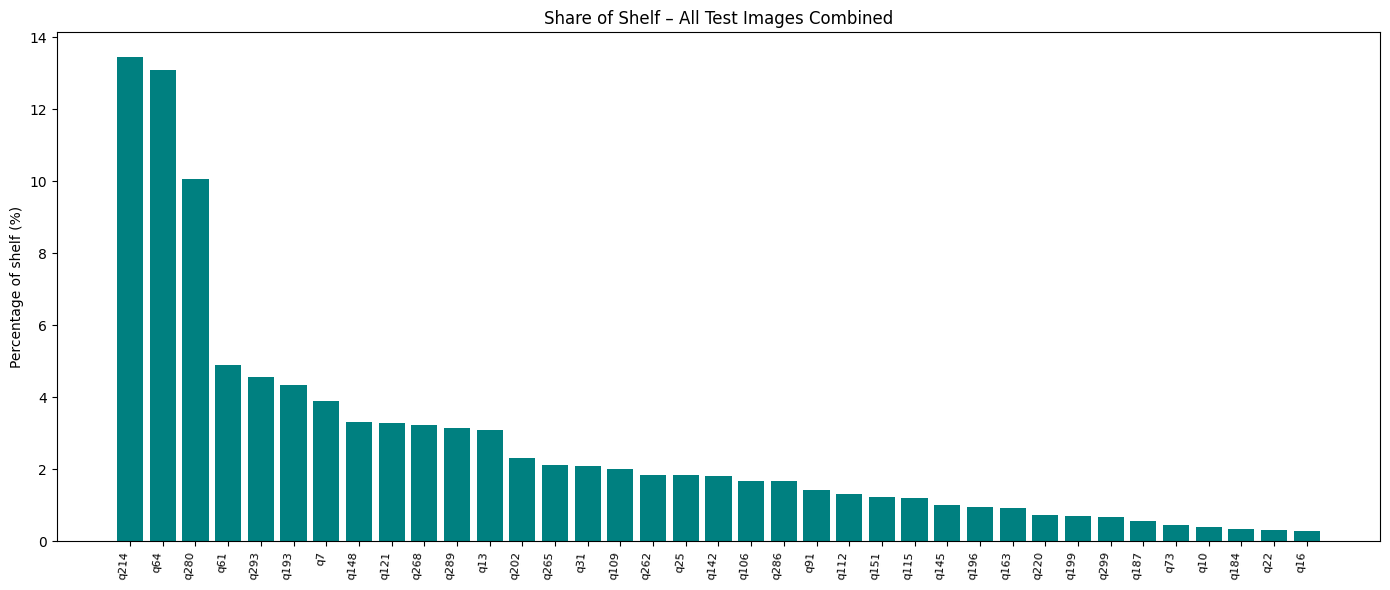


Pipeline complete.
Best weights → /kaggle/working/runs/detect/shelf_recall_opt/weights/best.pt
Results folder → /kaggle/working/runs/detect/shelf_recall_opt
→ Download notebook + best.pt + confusion_matrix.png + results.png for GitHub


In [7]:
# =============================================================================
#   ONE-CELL FULL PIPELINE – Shelf detection + Recall improvement + Share of Shelf
# =============================================================================

import os
from pathlib import Path
import yaml
from ultralytics import YOLO
from collections import defaultdict
import matplotlib.pyplot as plt
import glob
import numpy as np

# ────  CONFIG ────────────────────────────────────────────────────────────────
BASE_DIR = Path("/kaggle/input/datasets/fablihasarwar13/intelligent-machines-assignment")
WORKING_YAML = "/kaggle/working/data_for_training.yaml"

EPOCHS = 50               # increase to 80–100 if you have time
IMG_SIZE = 640
BATCH = 16                # lower to 8 if you get OOM
CONF_FOR_SHARE = 0.18     # lower → higher recall, lower precision

# ──── 1. Create corrected data.yaml with absolute paths ──────────────────────
print("Creating data.yaml with absolute paths...")
with open(BASE_DIR / "data.yaml") as f:
    data_cfg = yaml.safe_load(f)

data_cfg['train'] = str(BASE_DIR / "train/images")
data_cfg['val']   = str(BASE_DIR / "valid/images")
data_cfg['test']  = str(BASE_DIR / "test/images")

with open(WORKING_YAML, 'w') as f:
    yaml.dump(data_cfg, f, sort_keys=False)

print("data.yaml ready →", WORKING_YAML)

# ──── 2. Load model & train ──────────────────────────────────────────────────
print("\nStarting training...\n")

model = YOLO("yolov8s.pt")   # 'yolov8m.pt' if you want stronger but slower

train_results = model.train(
    data      = WORKING_YAML,
    epochs    = EPOCHS,
    imgsz     = IMG_SIZE,
    batch     = BATCH,
    patience  = 20,
    optimizer = "auto",
    lr0       = 0.01,
    cos_lr    = True,
    mosaic    = 1.0,
    mixup     = 0.15,
    copy_paste= 0.10,
    hsv_h     = 0.015, hsv_s=0.7, hsv_v=0.4,
    degrees   = 5.0,
    translate = 0.1,
    scale     = 0.5,
    shear     = 2.0,
    flipud    = 0.5,
    fliplr    = 0.5,
    name      = "shelf_recall_opt",
    device    = 0,
    plots     = True,
    amp       = True
)

print("\nTraining finished.")

# ──── 3. Evaluate on validation with different conf thresholds ───────────────
best_model = YOLO(f"{model.trainer.save_dir}/weights/best.pt")

print("\nValidation metrics @ default conf (~0.25)")
metrics_default = best_model.val(data=WORKING_YAML, split="val")

print("\nValidation metrics @ lower conf = 0.15 (recall-focused)")
metrics_low = best_model.val(
    data  = WORKING_YAML,
    split = "val",
    conf  = 0.15,
    iou   = 0.45
)

# ──── 4. Final evaluation on TEST set ────────────────────────────────────────
print("\nFinal TEST metrics @ conf=0.18")
test_metrics = best_model.val(
    data  = WORKING_YAML,
    split = "test",
    conf  = CONF_FOR_SHARE,
    iou   = 0.45,
    plots = True
)

# ──── 5. Share of Shelf – treat whole test set as one shelf ──────────────────
print("\nCalculating Share of Shelf on test set...")

test_img_paths = glob.glob(str(BASE_DIR / "test/images/*.[jpJP][pnPN][gG]*"))

class_total_width = defaultdict(float)
total_detected_width = 0.0

for img_p in test_img_paths:
    results = best_model(img_p, conf=CONF_FOR_SHARE, iou=0.45, verbose=False)
    for r in results:
        if r.boxes is None or len(r.boxes) == 0:
            continue
        boxes = r.boxes.xyxy.cpu().numpy()
        clss  = r.boxes.cls.cpu().numpy().astype(int)
        for box, cls_id in zip(boxes, clss):
            width = box[2] - box[0]           # x2 - x1
            class_total_width[cls_id] += width
            total_detected_width += width

# Compute percentages
share_dict = {}
for cls_id, w_sum in class_total_width.items():
    if total_detected_width > 0:
        perc = 100.0 * w_sum / total_detected_width
        name = data_cfg['names'][cls_id]
        share_dict[name] = perc

# Sort & print
print("\nShare of Shelf (test set as one shelf) – sorted descending")
print("─"*60)
for name, pct in sorted(share_dict.items(), key=lambda x: x[1], reverse=True):
    print(f"{name:>10} : {pct:5.2f} %")

# Bar chart
if share_dict:
    fig, ax = plt.subplots(figsize=(14, 6))
    names_sorted = sorted(share_dict, key=share_dict.get, reverse=True)
    values_sorted = [share_dict[n] for n in names_sorted]
    ax.bar(names_sorted, values_sorted, color='teal')
    ax.set_ylabel("Percentage of shelf (%)")
    ax.set_title("Share of Shelf – All Test Images Combined")
    plt.xticks(rotation=85, ha='right', fontsize=8)
    plt.tight_layout()
    plt.show()

print("\nPipeline complete.")
print("Best weights →", f"{model.trainer.save_dir}/weights/best.pt")
print("Results folder →", model.trainer.save_dir)
print("→ Download notebook + best.pt + confusion_matrix.png + results.png for GitHub")